<a href="https://colab.research.google.com/github/fboldt/aulasml/blob/master/aula04b_%C3%A1rvore_de_decis%C3%A3o_com_atributos_cont%C3%ADnuos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data[:,2:]
y = iris.target

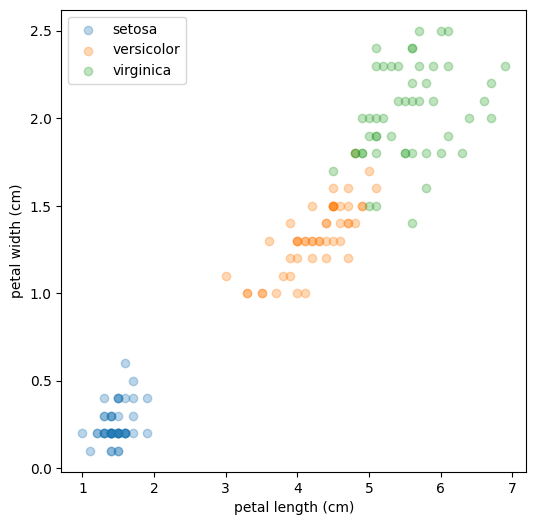

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
for i in range(3):
    plt.scatter(X[y==i,0],X[y==i,1],label=iris.target_names[i], alpha=0.3)
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.legend()
plt.show()

In [10]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score
import numpy as np

def most_frequent(arr):
  labels, counts = np.unique(arr, return_counts=True)
  return labels[np.argmax(counts)]

class ZeroR(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    self.answer = most_frequent(y)
    return self
  def predict(self, X):
    return [self.answer]*X.shape[0]

model = ZeroR()
model.fit(X, y)
y_pred = model.predict(X)
print(accuracy_score(y, y_pred))

0.3333333333333333


In [11]:
for label in set(y):
  print(f"{label}:\t{100*sum(y==label)/len(y):.4}%")

0:	33.33%
1:	33.33%
2:	33.33%


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    # stratify=y,
                                                    shuffle=True)

model = ZeroR()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.26666666666666666


In [83]:
import numpy as np

class DecisionTree(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    self.feature = np.random.randint(X.shape[1])
    self.value = np.random.choice(X[:,self.feature])
    greaters = X[:,self.feature] > self.value
    if sum(greaters) == 0 or sum(~greaters) == 0:
      self.answer = most_frequent(y)
    else:
      self.greaters = DecisionTree().fit(X[greaters], y[greaters])
      self.not_greaters = DecisionTree().fit(X[~greaters], y[~greaters])
    return self
  def predict(self, X):
    if hasattr(self, 'answer'):
      return [self.answer]*X.shape[0]
    else:
      greaters = X[:,self.feature] >= self.value
      return np.where(greaters, self.greaters.predict(X), self.not_greaters.predict(X))

model = DecisionTree()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.9666666666666667


In [84]:
def defineAxes(X):
  off_set = 0.1
  x_min, x_max = X[:, 0].min() - off_set, X[:, 0].max()
  y_min, y_max = X[:, 1].min() - off_set, X[:, 1].max()
  return x_min, x_max, y_min, y_max

def plotPredictions(model, X, y):
  x_min, x_max, y_min, y_max = defineAxes(X)
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
  plt.contourf(xx, yy, Z, alpha=0.3)

0.9333333333333333


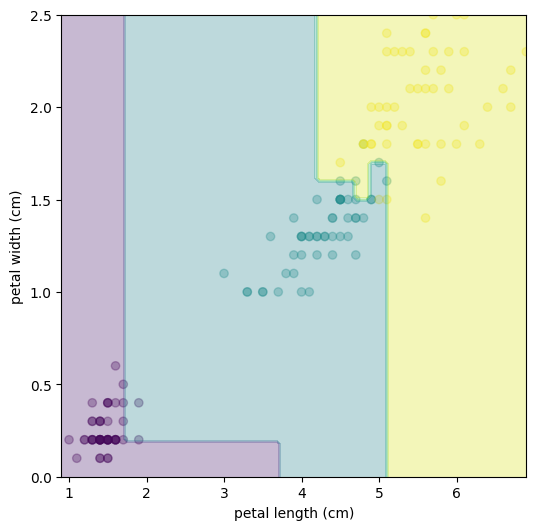

In [86]:
model = DecisionTree()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

def plotDecisionBoundary(model, X, y):
  plt.figure(figsize=(6,6))
  plt.scatter(X[:,0], X[:,1], c=y, alpha=0.3)
  plotPredictions(model, X, y)
  plt.xlabel(iris.feature_names[2])
  plt.ylabel(iris.feature_names[3])
  plt.show()

plotDecisionBoundary(model, X, y)

In [87]:
def gini(y):
  labels, counts = np.unique(y, return_counts=True)
  p = counts/sum(counts)
  return 1-sum(p**2)

print(gini(y_train))

0.6656944444444445


In [88]:
def impurity_value(x, y, value, impurity_function):
  greaters = x >= value
  greaters_impurity = impurity_function(y[greaters])
  not_greaters_impurity = impurity_function(y[~greaters])
  return (sum(greaters)*greaters_impurity + sum(~greaters)*not_greaters_impurity)/len(y)

print(impurity_value(X[:,0], y, 2.5, gini))

0.3333333333333333


In [89]:
def best_split(x, y, impurity_function):
  best_value = 0
  best_impurity = np.inf
  x = np.sort(x)
  for i in range(len(x)-1):
    value = (x[i]+x[i+1])/2
    impurity = impurity_value(x, y, value, impurity_function)
    if impurity < best_impurity:
      best_impurity = impurity
      best_value = value
  return best_value, best_impurity

print(best_split(X[:,1], y, gini))

(np.float64(0.8), np.float64(0.3333333333333333))


In [90]:
def best_feature(X, y, impurity_function):
  best_feature = 0
  best_value = 0
  best_impurity = np.inf
  for feature in range(X.shape[1]):
    value, impurity = best_split(X[:,feature], y, impurity_function)
    if impurity < best_impurity:
      best_feature = feature
      best_value = value
      best_impurity = impurity
  return best_feature, best_value, best_impurity

print(best_feature(X, y, gini))

(0, np.float64(2.45), np.float64(0.3333333333333333))


0.9666666666666667


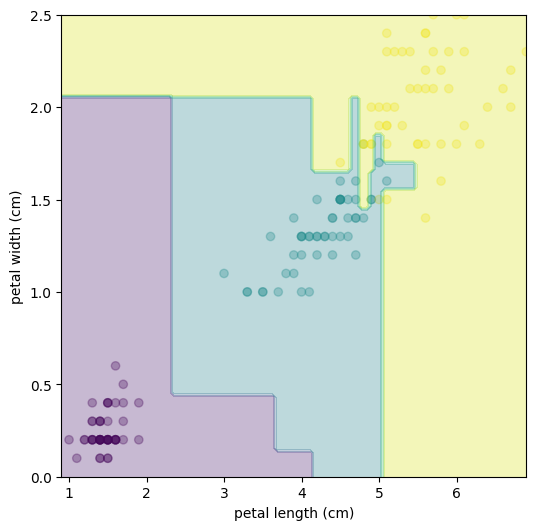

In [103]:
class DecisionTree(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    self.feature, self.value, self.impurity = best_feature(X, y, gini)
    greaters = X[:,self.feature] >= self.value
    if sum(greaters) == 0 or sum(~greaters) == 0:
      self.answer = most_frequent(y)
    else:
      self.greaters = DecisionTree().fit(X[greaters], y[greaters])
      self.not_greaters = DecisionTree().fit(X[~greaters], y[~greaters])
    return self
  def predict(self, X):
    if hasattr(self, 'answer'):
      return [self.answer]*X.shape[0]
    else:
      greaters = X[:,self.feature] >= self.value
      return np.where(greaters, self.greaters.predict(X), self.not_greaters.predict(X))

model = DecisionTree()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
plotDecisionBoundary(model, X, y)

0.9933333333333333


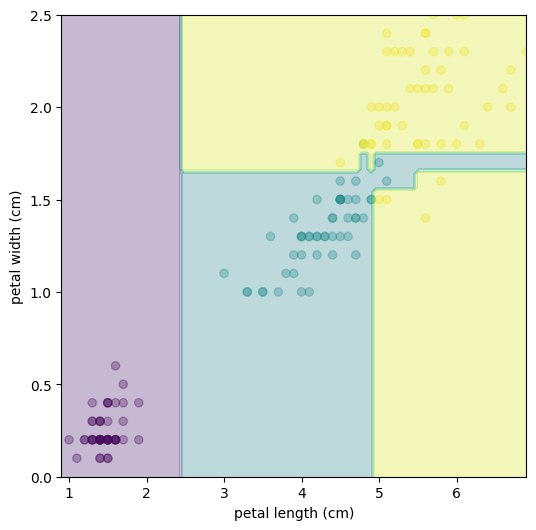

In [104]:
model = DecisionTree()
model.fit(X, y)
y_pred = model.predict(X)
print(accuracy_score(y, y_pred))
plotDecisionBoundary(model, X, y)

In [105]:
from sklearn.model_selection import cross_val_score, KFold

model = DecisionTree()
scores = cross_val_score(model, X, y, cv=KFold(5, shuffle=True))
print(scores)
print(scores.mean())

[0.96666667 0.96666667 0.96666667 0.86666667 0.96666667]
0.9466666666666667


0.9666666666666667


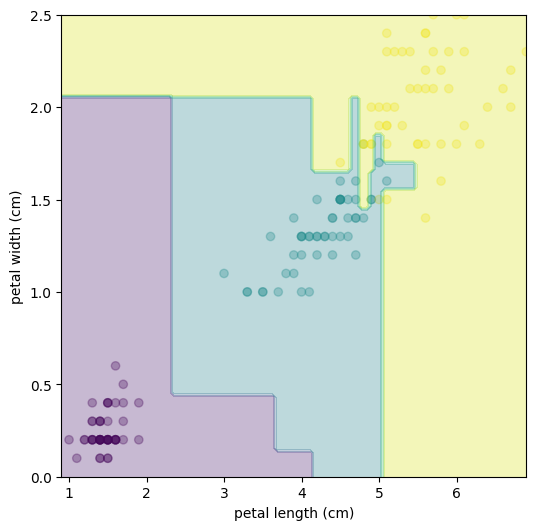

In [106]:
class DecisionTree(BaseEstimator, ClassifierMixin):
  def __init__(self, max_depth=1000, min_sample_split=1):
    self.max_depth = max_depth
    self.min_sample_split = min_sample_split
  def fit(self, X, y):
    self.feature, self.value, self.impurity = best_feature(X, y, gini)
    greaters = X[:,self.feature] >= self.value
    if sum(greaters) < self.min_sample_split or sum(~greaters) < self.min_sample_split or self.max_depth == 0:
      self.answer = most_frequent(y)
    else:
      self.greaters = DecisionTree(self.max_depth-1, self.min_sample_split).fit(X[greaters], y[greaters])
      self.not_greaters = DecisionTree(self.max_depth-1, self.min_sample_split).fit(X[~greaters], y[~greaters])
    return self
  def predict(self, X):
    if hasattr(self, 'answer'):
      return [self.answer]*X.shape[0]
    else:
      greaters = X[:,self.feature] >= self.value
      return np.where(greaters, self.greaters.predict(X), self.not_greaters.predict(X))

model = DecisionTree()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
plotDecisionBoundary(model, X, y)

0.8666666666666667


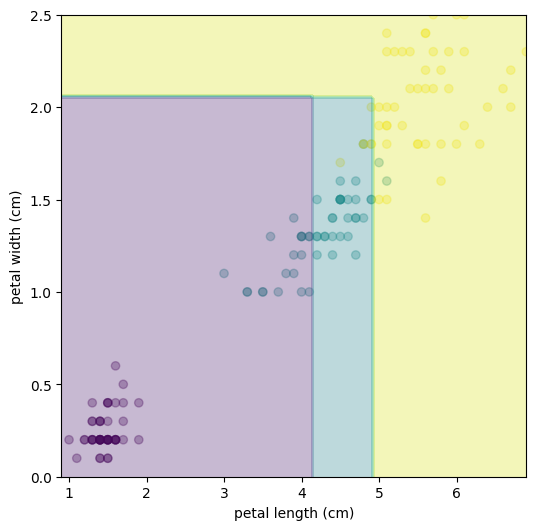

In [107]:
model = DecisionTree(10, 10)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
plotDecisionBoundary(model, X, y)

In [108]:
model = DecisionTree(10, 10)
scores = cross_val_score(model, X, y, cv=KFold(5, shuffle=True))
print(scores)
print(scores.mean())

[1.         0.93333333 0.9        0.93333333 1.        ]
0.9533333333333334


In [100]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 14.8 MB/s eta 0:00:00


In [110]:
import optuna

def objective(trial):
  max_depth = trial.suggest_int('max_depth', 1, 30)
  min_sample_split = trial.suggest_int('min_sample_split', 2, 20)

  model = DecisionTree(max_depth=max_depth, min_sample_split=min_sample_split)
  scores = cross_val_score(model, X, y, cv=KFold(5, shuffle=True))
  return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best trial:")
print(f"  Value: {study.best_value}")
print(f"  Params: {study.best_params}")


print("Final evaluation:")
model = DecisionTree(**study.best_params)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

[I 2026-09-15 00:48:30,928] A new study created in memory with name: no-name-044dc826-382b-4273-920f-193e6d1c797e
[I 2026-09-15 00:48:31,217] Trial 0 finished with value: 0.9466666666666667 and parameters: {'max_depth': 27, 'min_sample_split': 18}. Best is trial 0 with value: 0.9466666666666667.
[I 2026-09-15 00:48:31,502] Trial 1 finished with value: 0.9533333333333334 and parameters: {'max_depth': 20, 'min_sample_split': 11}. Best is trial 1 with value: 0.9533333333333334.
[I 2026-09-15 00:48:31,829] Trial 2 finished with value: 0.9666666666666666 and parameters: {'max_depth': 24, 'min_sample_split': 10}. Best is trial 2 with value: 0.9666666666666666.
[I 2026-09-15 00:48:32,120] Trial 3 finished with value: 0.9400000000000001 and parameters: {'max_depth': 27, 'min_sample_split': 4}. Best is trial 2 with value: 0.9666666666666666.
[I 2026-09-15 00:48:32,394] Trial 4 finished with value: 0.9533333333333334 and parameters: {'max_depth': 28, 'min_sample_split': 7}. Best is trial 2 with 

Best trial:
  Value: 0.9733333333333334
  Params: {'max_depth': 22, 'min_sample_split': 17}
Final evaluation:
0.8666666666666667


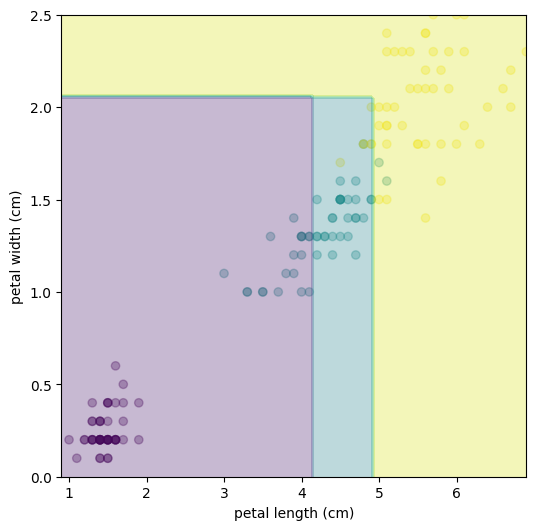

In [111]:
plotDecisionBoundary(model, X, y)